# Apéndice · 2 de 4 — ¿Hasta dónde sigue bajando el error con más datos?

Cuatro brazos sobre el dump de evaluaciones de Lichess, con los volúmenes que
[el survey](lichess_1_survey.ipynb) confirmó que hay (270 M posiciones
estimadas, mediana de profundidad 22-24):

| brazo | posiciones | red | parámetros |
|---|---|---|---|
| 1 | 5 M | ResNet 128 × 8 | 2.913.345 |
| 2 | 10 M | ResNet 128 × 8 | 2.913.345 |
| 3 | 30 M | ResNet 128 × 8 | 2.913.345 |
| 4 | **30 M** | **ResNet 128 × 16** | **5.276.737** |

Los tres primeros son **encajados** —el de 30 M contiene entero al de 10 M, que
contiene al de 5 M— así que entre ellos lo único que cambia es cuántas
posiciones distintas vio el modelo. Ésa es la curva.

El cuarto usa **exactamente los mismos 30 M** que el tercero y cambia sólo la
profundidad de la torre: 16 bloques en vez de 8. Es la comparación de capacidad,
directa y sin interpolar, en el punto donde más importa — con todos los datos,
que es donde una red chica tiene más chance de quedarse corta.

## Lo que ya sabemos y condiciona el diseño

- **La hipótesis viene del bloque 4.** Dos arquitecturas distintas empataron y
  empezaron a memorizar en el mismo punto, la señal de que el límite era el
  dataset (2,5 M de posiciones). Esta notebook lo pone a prueba con hasta doce
  veces más.
- **La distribución de etiquetas de Lichess es muy distinta.** La mitad de las
  posiciones no-mate caen entre −17 y +85 centipeones, pero los mates son el
  13 % de las filas (con profundidad 12 o más) contra el 1,4 % del proyecto, y
  cada uno es una etiqueta de ±1. Así que el RMSE de acá **no se compara** con
  el 0,2511 de la memoria, en ninguna dirección: el piso de la media constante
  da 0,57 contra 0,49 del proyecto. Por eso la tabla final trae los **pisos de
  referencia**, sin los cuales el número es ilegible, y la notebook 3 mide todos
  los modelos sobre el test del proyecto.
- **Bajar y parsear de corrido rinde 0,3 MB/s**, medidos en el survey. Por eso
  la descarga va en paralelo y las posiciones parseadas se publican en el Hub:
  la primera corrida paga la descarga, las demás no.

## Runtime y tiempo

**GPU y alta RAM.** El caché de 30 M son 35 GB y **tiene que entrar en memoria**:
si no entra, el entrenamiento lee filas sueltas del disco y la época pasa de
minutos a decenas de minutos.

Se corrió con `EPOCAS = 15`: **41 h de GPU** medidas (1,8 h el brazo de 5 M,
3,7 h el de 10 M, 15,2 h el de 30 M y 20,7 h el grande), más la descarga y el
caché. No entra en una sesión de Colab, y está previsto: los checkpoints van al Hub y los datos parseados también, así que
volver a correr desde cero cuesta bajar el parquet (~3 min) y reconstruir el
caché (~30 min), no rehacer el trabajo.

## 1. Entorno

In [2]:
# Clonar el repositorio e instalar el paquete.
# Idempotente: se puede volver a correr tal cual despues de una desconexion.
import os, sys, subprocess, importlib
from pathlib import Path

REPO_DIR = Path("/content/CEIA-TF-Chess-DL")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/zFonta/CEIA-TF-Chess-DL.git", str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], check=True)

# pip registra el paquete editable con un .pth, y los .pth solo se procesan al
# arrancar el interprete: un kernel que ya esta corriendo no lo ve. Agregar src/
# a sys.path lo hace visible sin tener que reiniciar el runtime.
src = str(REPO_DIR / "src")
if src not in sys.path:
    sys.path.insert(0, src)
importlib.invalidate_caches()

# Stockfish con version fija. Entrenar no lo usa, pero sin el se saltean los 17
# tests de integracion del pipeline, que son la evidencia del requerimiento 3.2.
subprocess.run(["bash", "scripts/setup_stockfish.sh"], check=True)
os.environ["PATH"] = f"{REPO_DIR}/bin:" + os.environ["PATH"]

print("Listo. Directorio de trabajo:", os.getcwd())

Listo. Directorio de trabajo: /content/CEIA-TF-Chess-DL


## 2. Credenciales

Un solo secreto: `HF_TOKEN`, **con permiso de escritura** — se sube el dataset
parseado y los checkpoints. Va en el panel de secretos de Colab (el ícono de la
llave). Se pide acá arriba para no descubrir que falta después de horas.

In [3]:
import numpy as np

from chessdl import hf
from chessdl.config import load_config

cfg = load_config()
token = hf.get_token(required=True)

REPO_DATOS   = 'zFonta/ceia-chess-work'
REPO_MODELOS = f'{cfg.output.hf_namespace}/{cfg.training.hf_models_repo}'
PREFIJO      = 'lichess_eval'            # carpeta dentro del repo de datos

print('token ok')
print('datos   ->', REPO_DATOS, f'/{PREFIJO}')
print('modelos ->', REPO_MODELOS, '/pruebas-lichess')

token ok
datos   -> zFonta/ceia-chess-work /lichess_eval
modelos -> zFonta/ceia-chess-models /pruebas-lichess


In [4]:
# --- lo que define la corrida -------------------------------------------------
OBJETIVO   = 32_000_000    # posiciones a juntar (30 M para el brazo grande + el test)
DEPTH_MIN  = 12            # el survey mostro 99,35 % por encima; saca los artefactos
VOLUMENES  = [5_000_000, 10_000_000, 30_000_000]
EPOCAS     = 15
TAM_BLOQUE = 1_000
TAM_SHARD  = 1_000_000
SEMILLA    = cfg.training.split_seed

# Bytes comprimidos por posicion, medidos en el survey. Se usa solo para saber
# cuanto bajar; si el dump cambio, la celda de parseo avisa y se baja mas.
BYTES_POR_POSICION = 82

URL = 'https://database.lichess.org/lichess_db_eval.jsonl.zst'
BASE = Path('/content/ceia-chess/lichess')
BASE.mkdir(parents=True, exist_ok=True)

print(f'objetivo   {OBJETIVO:,} posiciones con depth >= {DEPTH_MIN}')
print(f'brazos     {[f"{v:,}" for v in VOLUMENES]} con la red chica,')
print(f'           + uno de {VOLUMENES[-1]:,} con la grande')
print(f'shards     {OBJETIVO // TAM_SHARD} de {TAM_SHARD:,} filas')

objetivo   32,000,000 posiciones con depth >= 12
brazos     ['5,000,000', '10,000,000', '30,000,000'] con la red chica,
           + uno de 30,000,000 con la grande
shards     32 de 1,000,000 filas


## 3. Los datos

Dos caminos, y el primero es el que conviene:

1. **Ya están parseados en el Hub** → se bajan y listo, un par de minutos.
2. **No están** → se bajan de Lichess, se parsean y **se suben**, para que no
   haya que repetirlo nunca más.

Publicarlos no es sólo por velocidad. El dump de evaluaciones de Lichess **se
regenera y crece**: el que midió el survey es del 10 de septiembre de 2026.
Alguien que corra esto dentro de tres meses leería un archivo distinto y los
brazos no serían los mismos. Congelar el corte lo hace reproducible, que es
exactamente lo que el requerimiento 1.2 pide del dataset del proyecto.

Se guardan **centipeones sin normalizar**, no valores, por el mismo criterio con
el que el dataset del proyecto guarda FEN y no tensores: la transformación es
barata y puede querer cambiarse; volver a etiquetar, no.

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

ESQUEMA = pa.schema([
    pa.field('fen',   pa.string(), nullable=False),
    pa.field('cp',    pa.int32(),  nullable=False),   # sin normalizar, recortado despues
    pa.field('mate',  pa.int8()),                     # None si no hay mate
    pa.field('depth', pa.int16(), nullable=False),
])

N_SHARDS = OBJETIVO // TAM_SHARD
nombres = [f'{PREFIJO}/shard_{i:04d}.parquet' for i in range(N_SHARDS)]
carpeta_shards = BASE / 'shards'
carpeta_shards.mkdir(exist_ok=True)

EN_EL_HUB = hf.file_exists(REPO_DATOS, nombres[-1], token=token)
print('el ultimo shard ya esta en el Hub:', EN_EL_HUB)
if EN_EL_HUB:
    print('-> se bajan los', N_SHARDS, 'shards y se saltea el parseo')
else:
    print('-> hay que bajar de Lichess y parsear; despues se suben')

el ultimo shard ya esta en el Hub: True
-> se bajan los 32 shards y se saltea el parseo


### 3.1 Bajar el prefijo del dump

Sólo si hace falta, y **es la parte más frágil de la notebook**: son ~3 GB desde
un servidor que el survey midió a 0,3 MB/s por conexión. Tres decisiones, cada
una por un motivo concreto:

- **Se baja en paralelo** por rangos de bytes. Un stream zstd no se puede
  saltear, pero los bytes comprimidos sí, así que se piden ocho tramos a la vez
  y después se descomprime de corrido.
- **Cada tramo va a su propio archivo y se reanuda.** Si Colab se desconecta a
  las dos horas, volver a correr la celda retoma cada tramo donde quedó en vez
  de empezar de cero. Los pedazos se unen al final, cuando están los ocho
  completos.
- **La barra cuenta bytes, no tramos.** Una barra por tramos se queda en `0/8`
  durante toda la descarga —los ocho terminan juntos al final— y así no hay
  forma de distinguir "bajando" de "colgado".

El archivo final aparece **sólo cuando la descarga terminó entera**. Es lo que
hace que el chequeo de "ya está bajado" signifique algo: el archivo se
pre-reserva del tamaño total antes de escribirlo, así que su tamaño no dice
cuánto se bajó. Si un archivo a medias llevara el nombre definitivo, la próxima
corrida lo daría por completo y parsearía un archivo lleno de ceros.

In [6]:
import concurrent.futures as futuros
import shutil
import threading
import time

import requests
from tqdm.auto import tqdm

UA = {'User-Agent': 'chessdl/0.1 (CEIA-FIUBA; academico)'}


def bajar_prefijo(url: str, destino: Path, objetivo_bytes: int, hilos: int = 8) -> Path:
    """Bajar los primeros `objetivo_bytes` del archivo, en paralelo y reanudable.

    Cada tramo se guarda aparte y crece por agregado, asi que su tamaño en disco
    ES lo que lleva bajado y volver a llamar retoma desde ahi. Recien cuando los
    ocho estan completos se unen en `destino`, que por eso solo existe entero.
    """
    if destino.exists() and destino.stat().st_size >= objetivo_bytes:
        print(f'{destino.name} ya esta ({destino.stat().st_size/1e9:.2f} GB)')
        return destino

    cabeza = requests.head(url, allow_redirects=True, timeout=60, headers=UA)
    total = int(cabeza.headers.get('Content-Length', 0))
    objetivo_bytes = min(objetivo_bytes, total) if total else objetivo_bytes
    por_rangos = cabeza.headers.get('Accept-Ranges', '').lower() == 'bytes'
    print(f'{objetivo_bytes/1e9:.2f} GB a bajar; rangos en paralelo: {por_rangos}')

    carpeta = destino.parent / f'{destino.name}.partes'
    carpeta.mkdir(parents=True, exist_ok=True)
    if not por_rangos:                      # sin rangos no hay paralelo ni reanudacion
        hilos = 1
    tamano = objetivo_bytes // hilos + 1
    tramos = [(i, i * tamano, min((i + 1) * tamano, objetivo_bytes) - 1)
              for i in range(hilos)]

    def parte(i):
        return carpeta / f'parte_{i:02d}.bin'

    def hecho(i):
        return parte(i).stat().st_size if parte(i).exists() else 0

    ya = sum(hecho(i) for i, _, _ in tramos)
    if ya:
        print(f'reanudando: ya habia {ya/1e9:.2f} GB de {objetivo_bytes/1e9:.2f} GB')

    arranque = time.perf_counter()
    cerrojo = threading.Lock()
    with tqdm(total=objetivo_bytes, initial=ya, unit='B', unit_scale=True,
              desc='bajando') as barra:

        def bajar_tramo(tramo):
            i, desde, hasta = tramo
            largo = hasta - desde + 1
            desfase = hecho(i) if por_rangos else 0
            if desfase >= largo:
                return
            cabeceras = dict(UA)
            if por_rangos:
                cabeceras['Range'] = f'bytes={desde + desfase}-{hasta}'
            respuesta = requests.get(url, timeout=120, stream=True, headers=cabeceras)
            respuesta.raise_for_status()

            falta = largo - desfase
            escritos = 0
            with parte(i).open('ab' if por_rangos else 'wb') as fh:
                for trozo in respuesta.iter_content(1 << 20):
                    trozo = trozo[:falta - escritos]
                    if not trozo:
                        break
                    fh.write(trozo)
                    escritos += len(trozo)
                    with cerrojo:
                        barra.update(len(trozo))

        with futuros.ThreadPoolExecutor(hilos) as pool:
            list(pool.map(bajar_tramo, tramos))   # `list` propaga las excepciones

    cortos = [i for i, desde, hasta in tramos if hecho(i) < hasta - desde + 1]
    if cortos:
        faltantes = sum(hasta - desde + 1 - hecho(i) for i, desde, hasta in tramos)
        raise RuntimeError(
            f'quedaron cortos los tramos {cortos} ({faltantes/1e6:.0f} MB). '
            'Volve a correr esta celda: retoma donde quedo.')

    # Recien aca el archivo pasa a existir con su nombre definitivo.
    provisorio = destino.with_name(destino.name + '.uniendo')
    with provisorio.open('wb') as salida:
        for i, _, _ in tramos:
            with parte(i).open('rb') as fh:
                shutil.copyfileobj(fh, salida, 1 << 20)
    provisorio.replace(destino)
    shutil.rmtree(carpeta)

    dt = time.perf_counter() - arranque
    print(f'bajado en {dt/60:.1f} min  ({(objetivo_bytes - ya)/dt/1e6:.1f} MB/s)')
    return destino


RUTA_ZST = BASE / 'prefijo.jsonl.zst'

if not EN_EL_HUB:
    # 20 % de margen: el filtro de profundidad y la variacion del tamaño medio
    # de registro hacen que 82 bytes por posicion sea una estimacion, no un dato.
    bajar_prefijo(URL, RUTA_ZST, int(OBJETIVO * BYTES_POR_POSICION * 1.2))

### 3.2 Parsear a shards

Se toma, de cada posición, **la evaluación más profunda** y dentro de ella la
**primera línea** (`pvs[0]`): con MultiPV, las demás son jugadas peores, no
lecturas alternativas de la posición.

In [7]:
if not EN_EL_HUB:
    import io
    import json

    import zstandard as zstd
    from tqdm.auto import tqdm

    def leer(registro):
        mejor = max(registro['evals'], key=lambda e: e.get('depth', 0))
        linea = mejor['pvs'][0]
        return registro['fen'], linea.get('cp'), linea.get('mate'), mejor.get('depth', 0)

    fens, cps, mates, depths = [], [], [], []
    escritos = descartados = 0

    lector = zstd.ZstdDecompressor().stream_reader(RUTA_ZST.open('rb'), read_size=1 << 20)
    with io.TextIOWrapper(lector, encoding='utf-8', errors='replace') as flujo:
        with tqdm(total=OBJETIVO, desc='parseando', unit='pos') as barra:
            for linea in flujo:
                if escritos + len(fens) >= OBJETIVO:
                    break
                try:
                    fen, cp, mate, depth = leer(json.loads(linea))
                except Exception:
                    descartados += 1
                    continue
                if depth < DEPTH_MIN or (cp is None and mate is None):
                    descartados += 1
                    continue
                fens.append(fen)
                cps.append(cp if cp is not None else 0)
                mates.append(mate)
                depths.append(depth)
                barra.update(1)

                if len(fens) == TAM_SHARD:
                    indice = escritos // TAM_SHARD
                    pq.write_table(
                        pa.table({'fen': fens, 'cp': cps, 'mate': mates, 'depth': depths},
                                 schema=ESQUEMA),
                        carpeta_shards / f'shard_{indice:04d}.parquet', compression='zstd')
                    escritos += TAM_SHARD
                    fens, cps, mates, depths = [], [], [], []

    print(f'\nposiciones guardadas {escritos:,} en {escritos // TAM_SHARD} shards')
    print(f'descartadas          {descartados:,}')
    if escritos < OBJETIVO:
        print(f'AVISO: faltan {OBJETIVO - escritos:,}. Subi el margen de la celda '
              'anterior y volve a correr desde 3.1.')

In [8]:
from tqdm.auto import tqdm

if not EN_EL_HUB:
    hf.ensure_repo(REPO_DATOS, token=token, repo_type=hf.DATASET)
    for i in tqdm(range(escritos // TAM_SHARD), desc='subiendo'):
        local = carpeta_shards / f'shard_{i:04d}.parquet'
        hf.upload_file(local, REPO_DATOS, f'{PREFIJO}/shard_{i:04d}.parquet',
                       token=token, repo_type=hf.DATASET,
                       commit_message=f'lichess eval: shard {i:04d}')
    print('subidos. La proxima corrida los baja en minutos.')

In [9]:
from tqdm.auto import tqdm

if EN_EL_HUB:
    for nombre in tqdm(nombres, desc='bajando del Hub'):
        hf.download_file(REPO_DATOS, nombre, carpeta_shards / Path(nombre).name,
                         token=token, repo_type=hf.DATASET)

tabla = pq.read_table(sorted(carpeta_shards.glob('shard_*.parquet')),
                      columns=['fen', 'cp', 'mate', 'depth'])
fens = np.asarray(tabla['fen'])
cp_crudo = np.asarray(tabla['cp'], dtype=np.float64)
# Un mate "en 0" no existe, asi que el relleno con 0 sirve de marca de ausencia.
mate = np.asarray(tabla['mate'].fill_null(0), dtype=np.int16)
es_mate = mate != 0
profundidad = np.asarray(tabla['depth'])
del tabla

print(f'posiciones   {len(fens):,}')
print(f'mates        {es_mate.mean():.2%}')
print(f'profundidad  mediana {np.median(profundidad):.0f}, minima {profundidad.min()}')

bajando del Hub:   0%|          | 0/32 [00:00<?, ?it/s]

lichess_eval/shard_0000.parquet: reconstructing file:   0%|          |  0.00B / 16.5MB            

lichess_eval/shard_0000.parquet: downloading bytes:           |  0.00B            

lichess_eval/shard_0001.parquet: reconstructing file:   0%|          |  0.00B / 16.1MB            

lichess_eval/shard_0001.parquet: downloading bytes:           |  0.00B            

...

lichess_eval/shard_0030.parquet: reconstructing file:   0%|          |  0.00B / 16.4MB            

lichess_eval/shard_0030.parquet: downloading bytes:           |  0.00B            

lichess_eval/shard_0031.parquet: reconstructing file:   0%|          |  0.00B / 16.5MB            

lichess_eval/shard_0031.parquet: downloading bytes:           |  0.00B            

posiciones   32,000,000
mates        13.04%
profundidad  mediana 24, minima 12


## 4. De qué lado están escritas las etiquetas

El survey mostró un registro donde el `cp` parecía estar en perspectiva de las
blancas, pero eso fue **un registro**. Acá se decide sobre millones, comparando
la etiqueta con el material de las blancas **separado por quién mueve**: si la
perspectiva es la de las blancas, el signo del `cp` sigue al del material en los
dos casos; si es la del jugador al turno, se da vuelta cuando mueven negras.

Elegir mal no falla: entrena, converge, y devuelve un modelo que aprendió a
evaluar al revés la mitad de las posiciones.

**Se mide con el acuerdo de signos, no con una correlación.** Es la corrección
de un error propio: la primera versión de esta celda usaba la correlación de
Pearson con un umbral de 0,3, y sobre el dump de verdad dio `+0,232 / +0,198` —
o sea, cortó. No porque la convención fuera dudosa, sino porque Pearson es el
estadístico equivocado para este dump:

- el `cp` crudo **no está recortado** y tiene colas enormes, y Pearson es
  sensibilísimo a los valores extremos;
- **más de la mitad de las posiciones tienen el material igualado**, y ahí el
  material no dice nada del signo: son ruido puro que diluye el coeficiente.

Contar cuántas veces coinciden los signos, sólo entre las posiciones con
desequilibrio material, esquiva las dos cosas: no mira magnitudes y descarta las
filas que no tienen nada que aportar. Y el umbral deja de ser arbitrario —
**la frontera es el 50 %, el azar**.

Esa prueba **deja afuera los mates a propósito**, porque su `cp` no es una
evaluación sino un relleno: cuando Lichess anota un mate manda `mate` y no manda
`cp`, y la columna del parquet no admite nulos. Pero los mates son el 13 % de
las filas y se llevan las etiquetas más extremas (±0,9999), así que la
convención del campo `mate` tampoco puede quedar supuesta — se verifica aparte,
y contra el tablero en vez de contra una correlación.

El truco: quedarse sólo con las posiciones donde **el que mueve tiene mate en 1
de verdad**, comprobado con python-chess. Ahí las dos convenciones dicen cosas
distintas y no hay empate posible:

| | blancas al turno | **negras al turno** |
|---|---|---|
| POV blancas | `mate = +1` | **`mate = −1`** |
| POV del turno | `mate = +1` | **`mate = +1`** |

Las filas con negras al turno son las que deciden. Las otras coinciden bajo las
dos lecturas y no aportan nada, por eso se cuentan por separado.

In [10]:
import chess

VALOR = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3,
         chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0}

def material_blancas(fen: str) -> int:
    return sum(VALOR[chess.PIECE_SYMBOLS.index(c.lower())] * (1 if c.isupper() else -1)
               for c in fen.split(' ')[0] if c.isalpha())

# BARAJAR antes de cortar. Tomar las primeras 200.000 filas seria mirar el 0,6 %
# del archivo, entero adentro del primer shard -- y el dump viene ordenado, que
# es justo el motivo por el que la celda de brazos parte por bloques contiguos.
# Un prefijo de un archivo ordenado no es una muestra.
muestra = np.flatnonzero(~es_mate)
muestra = np.random.default_rng(SEMILLA).permutation(muestra)[:200_000]
muestra.sort()                       # leer ordenado, que el array es enorme

fens_m = fens[muestra]
blancas_m = np.array([f.split(' ')[1] == 'w' for f in fens_m])
material = np.array([material_blancas(f) for f in fens_m])
cp_m = cp_crudo[muestra]

# Solo donde hay desequilibrio: con el material igualado no tiene nada que decir
# sobre el signo, y es mas de la mitad del dump.
hay = material != 0

def acuerdo(mascara):
    m = hay & mascara
    return float(np.mean(np.sign(cp_m[m]) == np.sign(material[m]))), int(m.sum())

acu_b, n_b = acuerdo(blancas_m)
acu_n, n_n = acuerdo(~blancas_m)
senal_b, senal_n = acu_b - 0.5, acu_n - 0.5

print(f'con desequilibrio material: {hay.mean():.1%} de la muestra')
print('el signo del cp coincide con el del material en:')
print(f'   blancas al turno  {acu_b:>6.1%}   ({n_b:,} posiciones)')
print(f'   negras al turno   {acu_n:>6.1%}   ({n_n:,} posiciones)  <- el que decide')

con desequilibrio material: 52.5% de la muestra
el signo del cp coincide con el del material en:
   blancas al turno   60.4%   (53,266 posiciones)
   negras al turno    62.8%   (51,800 posiciones)  <- el que decide


In [11]:
def diagnostico():
    """Que mirar cuando el chequeo del signo no cierra."""
    print('\n' + '=' * 68)
    print('DIAGNOSTICO')
    print('=' * 68)

    print('\n1. Filas al azar: mirar si el cp le cierra a la posicion')
    for k in np.random.default_rng(0).choice(len(muestra), 6, replace=False):
        print(f'   {fens_m[k]}')
        print(f'      juegan {"blancas" if blancas_m[k] else "negras "}   '
              f'material {material[k]:+3d}   cp {cp_m[k]:+8.0f}   '
              f'depth {profundidad[muestra[k]]}')

    print('\n2. Acuerdo segun el tamaño del desequilibrio')
    print('   referencia, con Stockfish de verdad a depth 12 sobre partidas reales:')
    print('   |mat| 1 -> 65%   2 -> 76%   3-4 -> 79%   5-8 -> 78%   9+ -> 99%')
    for lo, hi in ((1, 1), (2, 2), (3, 4), (5, 8), (9, 99)):
        s = (np.abs(material) >= lo) & (np.abs(material) <= hi)
        if s.sum() > 100:
            a = np.mean(np.sign(cp_m[s]) == np.sign(material[s]))
            print(f'   |mat| {lo}-{"+" if hi == 99 else hi}: {a:>6.1%}  ({s.sum():,} pos)')

    print('\n3. Distribucion del cp')
    print('   referencia del survey:  p25 -17   p50 +14   p75 +85')
    print(f'   este dump:              p25 {np.percentile(cp_m, 25):+.0f}   '
          f'p50 {np.percentile(cp_m, 50):+.0f}   p75 {np.percentile(cp_m, 75):+.0f}'
          f'   |cp| max {np.abs(cp_m).max():,.0f}')
    print(f'   cp exactamente 0: {np.mean(cp_m == 0):.1%}   '
          '(con Stockfish real es ~0,5%; si es mucho mas, el parseo pierde el cp)')

    print('\n4. Acuerdo shard por shard')
    print('   si unos shards estan bien y otros no, hay shards viejos mezclados:')
    print(f'   borra {carpeta_shards} y volve a correr desde la seccion 3')
    rotos = []
    for s in range(len(fens) // TAM_SHARD):
        dentro = (muestra >= s * TAM_SHARD) & (muestra < (s + 1) * TAM_SHARD) & hay
        if dentro.sum() > 200:
            a = np.mean(np.sign(cp_m[dentro]) == np.sign(material[dentro]))
            if a < 0.60:
                rotos.append(s)
            print(f'   shard {s:04d}: {a:>6.1%}  ({dentro.sum():,} pos)'
                  f'{"   <-- sospechoso" if a < 0.60 else ""}')
    if rotos and len(rotos) < len(fens) // TAM_SHARD:
        print(f'\n   => {len(rotos)} shards sospechosos de {len(fens) // TAM_SHARD}: '
              'no es el dump, son esos shards.')
    print('=' * 68 + '\n')


# La señal minima. Medida, no elegida: con evaluaciones reales de Stockfish a
# depth 12 sobre posiciones de partidas reales el acuerdo da 76,1 % con blancas
# al turno y 74,7 % con negras -- o sea una señal de ~0,25. Pedir 0,10 deja un
# margen de 2,5 veces y sigue estando muy lejos del azar.
SENAL_MINIMA = 0.10

# Con blancas al turno el cp esta en perspectiva de las blancas bajo LAS DOS
# convenciones, asi que esto tiene que dar que si en cualquier caso. Si falla,
# el problema no es la perspectiva.
if senal_b < SENAL_MINIMA:
    diagnostico()
    raise AssertionError(
        f'con blancas al turno el acuerdo es {acu_b:.1%}, y las dos convenciones '
        f'predicen ~75%. Con blancas al turno el cp esta en POV blancas se mire '
        'como se mire, asi que esto no es un problema de perspectiva: los datos '
        'no se parecen a evaluaciones de ajedrez. Mira el diagnostico de arriba.')

if abs(senal_n) < SENAL_MINIMA:
    diagnostico()
    raise AssertionError(
        f'con negras al turno el acuerdo es {acu_n:.1%}, demasiado cerca del azar '
        'para decidir la convencion. Mira el diagnostico de arriba.')

# POV blancas => las dos señales iguales. POV del turno => opuestas y parejas en
# magnitud. Que una sea mucho mas debil que la otra no es ninguna de las dos.
if abs(abs(senal_b) - abs(senal_n)) > 0.08:
    diagnostico()
    raise AssertionError(
        f'las dos señales son de fuerza muy distinta ({senal_b:+.3f} contra '
        f'{senal_n:+.3f}). POV blancas las predice iguales y POV del turno '
        'opuestas pero parejas: esto no es ninguna de las dos.')

POV_BLANCAS = senal_n > 0
print('=> perspectiva de las BLANCAS: se invierte donde mueven negras' if POV_BLANCAS
      else '=> perspectiva del TURNO: se usan tal cual')

# La correlacion de Pearson sobre el cp crudo NO sirve para esto y queda como
# nota al pie: el cp sin recortar tiene colas enormes y mas de la mitad de las
# posiciones estan igualadas, asi que da bajisima (~0,2) aun cuando la
# convencion es clarisima. Su SIGNO sigue siendo informativo; su magnitud no.
corr_b = np.corrcoef(material[blancas_m], cp_m[blancas_m])[0, 1]
corr_n = np.corrcoef(material[~blancas_m], cp_m[~blancas_m])[0, 1]
print(f'   (Pearson, a titulo informativo: {corr_b:+.3f} / {corr_n:+.3f})')

=> perspectiva de las BLANCAS: se invierte donde mueven negras
   (Pearson, a titulo informativo: +0.241 / +0.236)


In [12]:
from tqdm.auto import tqdm

def da_mate_en_1(fen: str) -> bool:
    """Si el que mueve puede dar mate en una jugada. El dump trae 4 campos."""
    b = chess.Board(fen + ' 0 1')
    return any((b.push(m), b.is_checkmate(), b.pop())[1] for m in b.legal_moves)

candidatas = np.flatnonzero(np.abs(mate) == 1)
candidatas = np.random.default_rng(SEMILLA).permutation(candidatas)[:4_000]

utiles = negras = voto_blancas = voto_turno = 0
for i in tqdm(candidatas, desc='mates en 1'):
    fen = fens[i]
    if not da_mate_en_1(fen):
        continue                  # el mate lo da el rival: no distingue nada
    juegan_blancas = fen.split(' ')[1] == 'w'
    utiles += 1
    negras += not juegan_blancas
    voto_blancas += mate[i] == (1 if juegan_blancas else -1)
    voto_turno   += mate[i] == 1

print(f'mates en 1 confirmados en el tablero  {utiles:,}  '
      f'({negras:,} con negras al turno, que son los que deciden)')
print(f'coherentes con POV blancas {voto_blancas:,} | con POV del turno {voto_turno:,}')

assert negras >= 50, (
    f'solo {negras} mates en 1 con negras al turno: sin esas filas el chequeo '
    'no distingue una convencion de la otra')

POV_MATE_BLANCAS = voto_blancas > voto_turno
assert POV_MATE_BLANCAS == POV_BLANCAS, (
    f'`cp` esta en POV {"blancas" if POV_BLANCAS else "del turno"} pero `mate` '
    f'en POV {"blancas" if POV_MATE_BLANCAS else "del turno"}. La celda de '
    'etiquetas los trata igual: hay que separarlos antes de entrenar.')

print(f'=> `mate` va con `cp`: los dos en POV '
      f'{"BLANCAS" if POV_BLANCAS else "del TURNO"}')

mates en 1:   0%|          | 0/4000 [00:00<?, ?it/s]

mates en 1 confirmados en el tablero  2,458  (784 con negras al turno, que son los que deciden)
coherentes con POV blancas 2,458 | con POV del turno 1,674
=> `mate` va con `cp`: los dos en POV BLANCAS


In [13]:
from chessdl.normalize import DEFAULT_CP_CLIP, DEFAULT_SCALE, cp_to_value

def cps_a_valores(cp):
    """`cp_to_value` vectorizada: la del proyecto usa `math.tanh` y es escalar."""
    return np.tanh(np.clip(cp, -DEFAULT_CP_CLIP, DEFAULT_CP_CLIP) / DEFAULT_SCALE)

_c = np.array([-5000, -2000, -401, 0, 1, 400, 2000, 5000], dtype=float)
assert np.allclose(cps_a_valores(_c), [cp_to_value(v) for v in _c])

turno_blancas = np.array([f.split(' ')[1] == 'w' for f in fens])

# Los mates al tope del recorte, igual que en el pipeline del proyecto. El signo
# sale del campo `mate`, no del `cp`, que para esas filas vale 0.
cp = np.where(es_mate, np.sign(mate) * DEFAULT_CP_CLIP, cp_crudo)

cp_white = cp if POV_BLANCAS else np.where(turno_blancas, cp, -cp)
value_white = cps_a_valores(cp_white)
targets = np.where(turno_blancas, value_white, -value_white).astype(np.float32)

del cp_crudo, cp, cp_white, value_white, mate
print(f'blancas al turno  {turno_blancas.mean():.2%}')
print(f'value_stm         media {targets.mean():+.4f}, desvio {targets.std():.4f}')
print(f'|value| > 0,99    {np.mean(np.abs(targets) > 0.99):.2%}  '
      f'(los mates mas todo lo que pase de ~1060 cp)')

blancas al turno  51.31%
value_stm         media +0.0357, desvio 0.5689
|value| > 0,99    15.10%  (los mates mas todo lo que pase de ~1060 cp)


### 4.2 Los cuatro casos de mate

El mate tiene **cuatro** situaciones, no dos: el que mueve puede ser el que da
mate o el que se lo come, y eso es independiente de su color. La celda anterior
decidió *cómo leer* el signo del dump; ésta comprueba que los cuatro lleguen al
entrenamiento y que cada uno salga con el target que le toca.

La propiedad, que vale para toda fila de mate y es la que hace falta para la
codificación en perspectiva del jugador al turno:

> **`target > 0` exactamente cuando el que mueve es el que da mate.**

Se verifica contra el tablero **en las dos direcciones** — posiciones donde el
que mueve mata ya, y posiciones donde lo matan a él juegue lo que juegue — que
es lo que cubre los cuatro casos. Hace falta así: con los signos dados vuelta,
la tabla de conteos sigue mostrando los cuatro casos, sólo que intercambiados.
Sola no alcanza.

In [14]:
from tqdm.auto import tqdm

# Los mates son cuatro casos, no dos: el que mueve puede ser el que mata o el
# que se come el mate, y eso es independiente de su color. La celda anterior
# decidio COMO LEER el signo del dump; esta comprueba que los cuatro casos
# lleguen al dataset y que cada uno salga con el target que le toca.

# El target esta en perspectiva del que mueve; darlo vuelta donde mueven negras
# lo pone en perspectiva de las blancas, que es lo que permite nombrar al que mata.
en_pov_blancas = np.where(turno_blancas, targets, -targets)
blancas_matan = en_pov_blancas > 0

total_mates = int(es_mate.sum())
print(f"{'mueve':<10}{'da mate':<10}{'filas':>13}{'de los mates':>14}{'target':>9}")
print('-' * 56)
for tb in (True, False):
    for bm in (True, False):
        cuantas = int((es_mate & (turno_blancas == tb) & (blancas_matan == bm)).sum())
        assert cuantas > 0, (
            f'no hay ni una fila con {"blancas" if tb else "negras"} al turno y '
            f'{"blancas" if bm else "negras"} dando mate: falta un caso entero')
        print(f'{"blancas" if tb else "negras":<10}{"blancas" if bm else "negras":<10}'
              f'{cuantas:>13,}{cuantas / total_mates:>13.1%}'
              f'{"+" if bm == tb else "-":>9}')
print('-' * 56)
print(f'{"":<20}{total_mates:>13,}{"100.0%":>13}   ninguna fila se descarta')


def _mate_ya(b) -> bool:
    """El que mueve da mate en esta jugada."""
    for m in b.legal_moves:
        b.push(m)
        es = b.is_checkmate()
        b.pop()
        if es:
            return True
    return False


def _lo_matan_ya(b) -> bool:
    """Al que mueve lo matan en la siguiente, juegue lo que juegue."""
    if not any(b.legal_moves) or _mate_ya(b):
        return False
    for m in b.legal_moves:
        b.push(m)
        pierde = _mate_ya(b)
        b.pop()
        if not pierde:
            return False
    return True


# La propiedad, contra el tablero y en las DOS direcciones -- que es lo que
# cubre los cuatro casos de la tabla de arriba:
#     target > 0  <=>  el que mueve es el que da mate
INTENTOS = 6_000
sospechosas = np.random.default_rng(SEMILLA).permutation(np.flatnonzero(es_mate))
mata = lo_matan = 0
for i in tqdm(sospechosas[:INTENTOS], desc='verificando el signo'):
    tablero = chess.Board(fens[i] + ' 0 1')
    if _mate_ya(tablero):
        assert targets[i] > 0, (
            f'el que mueve DA mate y el target es {targets[i]:+.4f}: {fens[i]}')
        mata += 1
    elif _lo_matan_ya(tablero):
        assert targets[i] < 0, (
            f'al que mueve LO matan y el target es {targets[i]:+.4f}: {fens[i]}')
        lo_matan += 1

assert mata + lo_matan >= 100, (
    f'solo {mata + lo_matan} posiciones verificables en {INTENTOS:,}: muy pocas '
    'para afirmar nada del signo')
print(f'\nverificadas contra el tablero, de {INTENTOS:,} mates al azar:')
print(f'   {mata:>6,} donde el que mueve DA mate  -> target positivo')
print(f'   {lo_matan:>6,} donde al que mueve LO matan -> target negativo')
print('   (el resto son mates en 3, 5, 7... que no se confirman con una jugada)')

mueve     da mate           filas  de los mates   target
--------------------------------------------------------
blancas   blancas       1,675,510        40.2%        +
blancas   negras          592,820        14.2%        -
negras    blancas       1,215,462        29.1%        -
negras    negras          688,765        16.5%        +
--------------------------------------------------------
                        4,172,557       100.0%   ninguna fila se descarta


verificando el signo:   0%|          | 0/6000 [00:00<?, ?it/s]


verificadas contra el tablero, de 6,000 mates al azar:
      438 donde el que mueve DA mate  -> target positivo
      302 donde al que mueve LO matan -> target negativo
   (el resto son mates en 3, 5, 7... que no se confirman con una jugada)


### 4.3 Cómo quedó repartido el target

Dos cosas distintas. La izquierda es el control de cordura antes de un día de
GPU: los mates tienen que verse apilados en los dos extremos y en la proporción
que dijo el survey. La derecha es lo que hace legible el RMSE de la tabla final:
el núcleo es angosto —un 22 % de las etiquetas cae a menos de 0,05 del cero—,
pero los mates pesan tanto que predecir cero constante da un RMSE de 0,57, más
alto que en el dataset del proyecto.

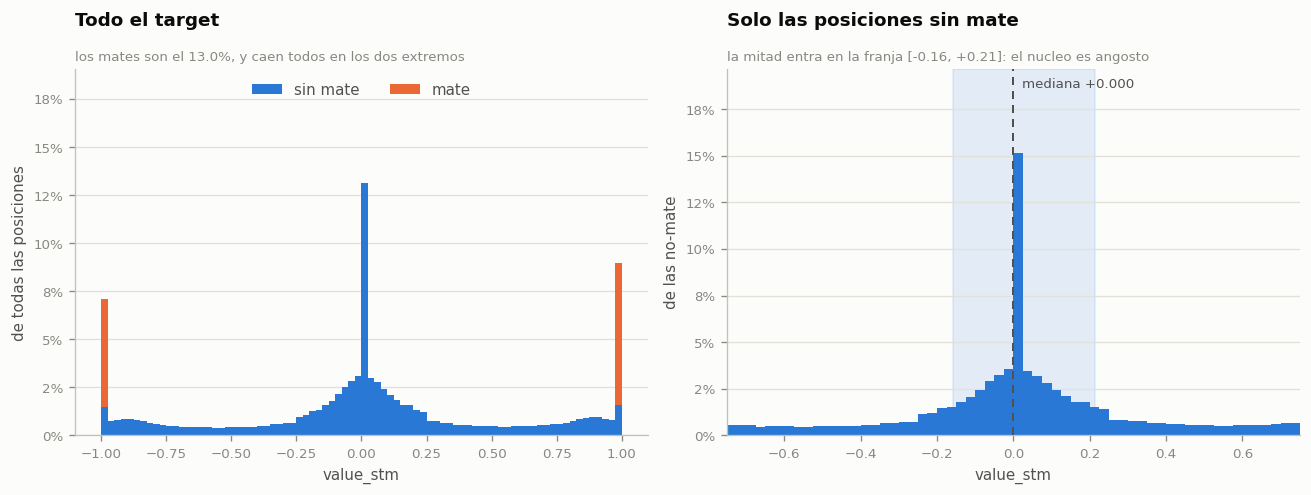

mates                        13.04%
cuartiles de las no-mate   -0.159 / +0.000 / +0.214
|target| < 0,05              22.05%

Los pisos, que son lo que hace legible el RMSE de la tabla final:
   predecir siempre 0          RMSE 0.5701
   predecir siempre la media   RMSE 0.5689


In [15]:
import matplotlib.pyplot as plt

from chessdl import viz

viz.apply_style()

# Las cuentas salen de los histogramas y no de copias del array: el de no-mate
# se obtiene restando, para no materializar 27 M de floats al pedo.
BORDES = np.linspace(-1, 1, 81)
ancho = BORDES[1] - BORDES[0]
centros = (BORDES[:-1] + BORDES[1:]) / 2
todo, _ = np.histogram(targets, bins=BORDES)
solo_mates, _ = np.histogram(targets[es_mate], bins=BORDES)
sin_mate = todo - solo_mates

nucleo = targets[~es_mate]
q1, q2, q3 = np.percentile(nucleo, [25, 50, 75])
piso_cero = float(np.sqrt(np.mean(targets ** 2)))     # RMSE de predecir siempre 0
piso_media = float(targets.std())                     # RMSE de predecir la media
del nucleo

fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 4.2))

# --- izquierda: el target entero, con los mates apilados arriba
altura_sin = sin_mate / len(targets)
altura_mate = solo_mates / len(targets)
izq.bar(centros, altura_sin, width=ancho, color=viz.SERIES[0], label='sin mate')
izq.bar(centros, altura_mate, width=ancho, bottom=altura_sin,
        color=viz.SERIES[1], label='mate')
izq.set_ylim(0, (altura_sin + altura_mate).max() * 1.45)
izq.legend(loc='upper center', ncols=2)
viz.label_axes(izq, 'Todo el target', 'value_stm', 'de todas las posiciones',
               note=f'los mates son el {es_mate.mean():.1%}, y caen todos en los '
                    'dos extremos')

# --- derecha: solo las no-mate, que es donde la red tiene algo que aprender
altura_nucleo = sin_mate / sin_mate.sum()
der.bar(centros, altura_nucleo, width=ancho, color=viz.SERIES[0])
der.set_xlim(-0.75, 0.75)
visible = altura_nucleo[(centros > -0.75) & (centros < 0.75)].max()
der.set_ylim(0, visible * 1.3)
der.axvspan(q1, q3, color=viz.SERIES[0], alpha=0.12, zorder=0)
der.axvline(q2, color=viz.INK_SECONDARY, linewidth=1.2, linestyle=(0, (4, 3)),
            zorder=3)
# Arriba del todo, en coordenadas del eje: asi no hay forma de que pise las barras.
der.annotate(f'mediana {q2:+.3f}', xy=(q2, 1.0), xycoords=('data', 'axes fraction'),
             xytext=(5, -11), textcoords='offset points',
             fontsize=8, color=viz.INK_SECONDARY)
viz.label_axes(der, 'Solo las posiciones sin mate', 'value_stm', 'de las no-mate',
               note=f'la mitad entra en la franja [{q1:+.2f}, {q3:+.2f}]: '
                    'el nucleo es angosto')

for eje in (izq, der):
    eje.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
fig.tight_layout()
plt.show()

print(f'mates                      {es_mate.mean():>8.2%}')
print(f'cuartiles de las no-mate   {q1:+.3f} / {q2:+.3f} / {q3:+.3f}')
print(f'|target| < 0,05            {np.mean(np.abs(targets) < 0.05):>8.2%}')
print()
print('Los pisos, que son lo que hace legible el RMSE de la tabla final:')
print(f'   predecir siempre 0          RMSE {piso_cero:.4f}')
print(f'   predecir siempre la media   RMSE {piso_media:.4f}')

## 5. Los brazos

Un bloque de cada veinte queda reservado como **test**, el mismo para los
cuatro. Otro de cada veinte es validación, que sólo elige la mejor época.

Se parte por bloques contiguos porque el dump viene ordenado y las posiciones
cercanas pueden venir de la misma partida analizada. El orden del pool se baraja
acá, y el caché se escribe en ese orden: eso es lo que hace que cada brazo sea a
la vez una muestra aleatoria y un **prefijo contiguo del archivo de caché**, de
lo que depende que el entrenamiento lea de RAM y no de disco.

In [16]:
bloque = np.arange(len(fens)) // TAM_BLOQUE
es_test = (bloque % 20) == 1
es_val  = (bloque % 20) == 0

pool = np.flatnonzero(~es_test)
pool = pool[np.random.default_rng(SEMILLA).permutation(len(pool))]
test = np.flatnonzero(es_test)[:200_000]

faltan = [v for v in VOLUMENES if v > len(pool)]
assert not faltan, f'el pool tiene {len(pool):,}; no alcanza para {faltan}'

print(f'pool  {len(pool):>12,}')
print(f'test  {len(test):>12,}')
print(f'val   {es_val.mean():>11.1%} de cada brazo')

pool    30,400,000
test       200,000
val          5.0% de cada brazo


## 6. Caché de tensores

La codificación a los 18 planos es la del proyecto, sin tocar — el espejado a
perspectiva del jugador al turno pasa adentro de `board_to_tensor`.

El chequeo de velocidad que sigue mide la lectura **directo del archivo**, y da
lento: el sistema no retiene el caché en memoria entre lecturas al azar. No es
un problema de RAM sino de cómo se lee, y por eso el entrenamiento (sección 7)
copia antes cada brazo a RAM —un prefijo contiguo del archivo—, que es lo que
baja la lectura a menos de un milisegundo por lote.

In [17]:
from chessdl.training.cache import build_cache, cache_size_bytes, load_cache

ruta_pool, ruta_test = BASE / 'pool.npy', BASE / 'test.npy'
print(f'caché del pool: {cache_size_bytes(len(pool))/1e9:>5.1f} GB')
print(f'caché del test: {cache_size_bytes(len(test))/1e9:>5.1f} GB')

if not ruta_pool.exists():
    build_cache(fens[pool], ruta_pool, progress=True)
if not ruta_test.exists():
    build_cache(fens[test], ruta_test, progress=True)

cache_pool = load_cache(ruta_pool, expected_rows=len(pool))
cache_test = load_cache(ruta_test, expected_rows=len(test))

targets_pool, targets_test = targets[pool], targets[test]
val_pool = es_val[pool]

del fens, targets, es_mate, profundidad, turno_blancas
print('listo')

caché del pool:  35.0 GB
caché del test:   0.2 GB


encoding:   0%|          | 0/30400000 [00:00<?, ?pos/s]

encoding:   0%|          | 0/200000 [00:00<?, ?pos/s]

listo


In [18]:
import time

# Cinco segundos de chequeo antes de un dia de GPU. Si leer un lote tarda
# cientos de milisegundos, el entrenamiento va a estar limitado por disco.
rng = np.random.default_rng(0)
for etiqueta, hasta in (('brazo chico', VOLUMENES[0]), ('brazo grande', VOLUMENES[-1])):
    medidas = []
    for _ in range(6):
        lote = np.sort(rng.choice(hasta, 1024, replace=False))
        t = time.perf_counter(); np.asarray(cache_pool[lote])
        medidas.append((time.perf_counter() - t) * 1000)
    ms = float(np.median(medidas))
    print(f'{etiqueta:<14}{ms:>7.1f} ms por lote   '
          f'{"bien, lee de RAM" if ms < 50 else "desde disco: la seccion 7 copia cada brazo a RAM"}')

brazo chico    1204.1 ms por lote   desde disco: la seccion 7 copia cada brazo a RAM
brazo grande    240.7 ms por lote   desde disco: la seccion 7 copia cada brazo a RAM


## 7. Entrenar

Los cuatro brazos con los hiperparámetros de `campana2-warmup`, que es la
condición de la prueba. Lo único que cambia entre los tres primeros es el
volumen, y entre el tercero y el cuarto, la profundidad de la torre.

Los checkpoints van al Hub bajo `pruebas-lichess/`. Si Colab recicla la VM,
volver a correr esta celda retoma desde la última época en vez de empezar de
cero — que con 41 horas de corrida no es un lujo.

In [19]:
import gc
import os
import time

import psutil
import torch
from tqdm.auto import tqdm

from chessdl.models.resnet import ChessResNet, ResNetConfig
from chessdl.training.checkpoint import BEST_NAME, HubCheckpoints
from chessdl.training.loop import seed_everything, train

CHICA  = ResNetConfig(channels=128, blocks=8)     # la de campana2-warmup
GRANDE = ResNetConfig(channels=128, blocks=16)    # 5,28 M: solo cambia la profundidad


def etiqueta(v: int) -> str:
    """`5M`, `10M`, `500k`: nombre corto y, sobre todo, distinto por volumen."""
    if v % 1_000_000 == 0:
        return f'{v // 1_000_000}M'
    if v % 1_000 == 0:
        return f'{v // 1_000}k'
    return str(v)


BRAZOS = [(v, CHICA, f'{etiqueta(v)}-chica') for v in VOLUMENES]
BRAZOS.append((VOLUMENES[-1], GRANDE, f'{etiqueta(VOLUMENES[-1])}-grande'))

# El nombre es la identidad del checkpoint en el Hub. Si dos brazos comparten
# nombre, el segundo NO entrena: `train` reanuda el del primero y devuelve su
# historial, sin avisar.
nombres_brazos = [n for _, _, n in BRAZOS]
assert len(set(nombres_brazos)) == len(nombres_brazos), (
    f'brazos con nombre repetido: {nombres_brazos}')


def a_ram(volumen):
    """Traer el prefijo del brazo a RAM de verdad, sin fiarse de la cache de paginas.

    `load_cache` mapea el archivo (`mmap_mode='r'`), asi que cada lote son ~1000
    lecturas salteadas sobre 35 GB. Si el kernel no retuvo esas paginas -- y no
    las retuvo: la RAM se quedo en 7 GB de 51 -- cada lote paga ~1000 accesos a
    disco. Medido: ~320 ms, contra los ~100 que tarda la GPU.

    Los brazos son prefijos contiguos justamente para que esto sea una lectura
    secuencial, que es el unico acceso que el disco hace rapido.
    """
    hacen_falta = volumen * 1152
    libre = psutil.virtual_memory().available
    if hacen_falta > libre * 0.85:
        raise MemoryError(
            f'el brazo necesita {hacen_falta/1e9:.1f} GB y hay {libre/1e9:.1f} GB '
            'libres. Pedila mas grande (la A100 viene con 83 GB) y volve a correr: '
            'los checkpoints ya guardados se reanudan.')

    fuente = np.load(ruta_pool, mmap_mode='r')
    destino = np.empty((volumen, *fuente.shape[1:]), dtype=fuente.dtype)
    PASO = 250_000
    t = time.perf_counter()
    for i in tqdm(range(0, volumen, PASO), desc=f'{hacen_falta/1e9:.1f} GB a RAM'):
        hasta = min(i + PASO, volumen)      # el ultimo trozo no llega a PASO,
        destino[i:hasta] = fuente[i:hasta]  # y la fuente tiene MAS filas que el brazo
    del fuente

    # Soltar las paginas del archivo: los bytes ya estan en `destino`, y en el
    # brazo de 30M el duplicado no entraria en memoria.
    with open(ruta_pool, 'rb') as fh:
        os.posix_fadvise(fh.fileno(), 0, 0, os.POSIX_FADV_DONTNEED)

    seg = time.perf_counter() - t
    print(f'   {hacen_falta/1e9:.1f} GB en {seg/60:.1f} min ({hacen_falta/seg/1e6:.0f} MB/s)')

    rng = np.random.default_rng(0)
    medidas = []
    for _ in range(6):
        lote = np.sort(rng.choice(volumen, 1024, replace=False))
        t = time.perf_counter()
        np.asarray(destino[lote])
        medidas.append((time.perf_counter() - t) * 1000)
    ms = float(np.median(medidas))
    print(f'   {ms:.1f} ms por lote  '
          f'{"(bien: ahora lee de RAM)" if ms < 50 else "(SIGUE LENTO, algo mas pasa)"}')
    return destino


cache_brazo, volumen_en_ram = None, None
corridas, guardados = {}, {}

for volumen, config, nombre in BRAZOS:
    # Los dos brazos de 30M comparten volumen: se carga una sola vez.
    if volumen != volumen_en_ram:
        cache_brazo = None          # soltar el anterior ANTES de pedir el siguiente
        gc.collect()
        cache_brazo = a_ram(volumen)
        volumen_en_ram = volumen

    idx_val = np.flatnonzero(val_pool[:volumen])
    idx_train = np.flatnonzero(~val_pool[:volumen])
    parametros = sum(p.numel() for p in ChessResNet(config).parameters())
    print(f'\n=== {nombre}: {len(idx_train):,} entrenamiento, '
          f'{config.blocks} bloques, {parametros:,} parametros ===')

    # Sembrar ANTES de construir la red: `train` tambien siembra, pero para
    # entonces los pesos iniciales ya salieron de donde estuviera el interprete,
    # y cada brazo arrancaria de un lugar distinto -- una diferencia del mismo
    # tamaño que el efecto que se quiere medir.
    seed_everything(SEMILLA)

    guardados[nombre] = HubCheckpoints(
        repo_id=REPO_MODELOS, run_name=f'pruebas-lichess/{nombre}',
        local_dir=str(BASE / 'checkpoints'), token=token, enabled=True,
    )
    corridas[nombre] = train(
        ChessResNet(config), cache_brazo, targets_pool, idx_train, idx_val,
        epochs=EPOCAS,
        batch_size=1024, learning_rate=1e-3, weight_decay=1e-4,
        loss_name='mse', warmup_epochs=2, seed=SEMILLA,
        checkpoints=guardados[nombre],
        model_config={'channels': config.channels, 'blocks': config.blocks},
    )
    print(corridas[nombre].summary())

5.8 GB a RAM:   0%|          | 0/20 [00:00<?, ?it/s]

   5.8 GB en 0.4 min (264 MB/s)
   0.4 ms por lote  (bien: ahora lee de RAM)

=== 5M-chica: 4,736,459 entrenamiento, 8 bloques, 2,913,345 parametros ===


pruebas-lichess/5M-chica/checkpoint_last(…): reconstructing file:   0%|          |  0.00B / 35.1MB            

pruebas-lichess/5M-chica/checkpoint_last(…): downloading bytes:           |  0.00B            

Reanudando desde la epoca 15.
 epoca     train   val RMSE   val MAE   MAE cp    signo     rho     seg
-----------------------------------------------------------------------
     1   0.15176     0.3744    0.2606    332.8   80.2%  0.7174     453
     2   0.13032     0.3565    0.2497    317.9   81.0%  0.7371     432
     3   0.11553     0.3784    0.2679    307.2   79.1%  0.7504     431
     4   0.10211     0.3849    0.2731    301.6   74.1%  0.7774     431
     5   0.09309     0.3128    0.2078    265.6   85.3%  0.7971     432
     6   0.08591     0.3142    0.2111    256.6   84.9%  0.8057     435
     7   0.07952     0.2963    0.1883    247.6   87.8%  0.8212     435
     8   0.07372     0.3556    0.2593    271.3   80.7%  0.7924     434
     9   0.06800     0.2927    0.1852    229.2   87.7%  0.8299     433
    10   0.06237     0.2991    0.1885    228.9   86.3%  0.8261     433
    11   0.05693     0.2918    0.1808    221.0   88.0%  0.8301     433
    12   0.05209     0.2910    0.1761    215.

...

epoca  15  perdida 0.03080  RMSE 0.2410  MAE 0.1340  MAEcp  163.2  signo 92.3%  rho 0.8853


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...grande/checkpoint_last.pt:   0%|          | 25.1kB / 63.5MB            

 epoca     train   val RMSE   val MAE   MAE cp    signo     rho     seg
-----------------------------------------------------------------------
     1   0.11344     0.3300    0.2137    262.9   85.2%  0.8021    5019
     2   0.09213     0.2863    0.1843    236.8   87.7%  0.8347    4977
     3   0.07742     0.2768    0.1734    224.0   88.8%  0.8507    4960
     4   0.06645     0.2626    0.1617    213.9   90.3%  0.8619    4954
     5   0.06033     0.2509    0.1530    203.0   91.0%  0.8713    4951
     6   0.05572     0.2480    0.1492    199.6   91.3%  0.8760    4950
     7   0.05185     0.2445    0.1460    192.7   91.6%  0.8788    4948
     8   0.04829     0.2445    0.1449    188.5   91.4%  0.8792    4952
     9   0.04491     0.2415    0.1407    181.3   91.9%  0.8821    4953
    10   0.04167     0.2406    0.1387    176.9   92.0%  0.8834    4952
    11   0.03862     0.2404    0.1382    172.3   91.9%  0.8852    4955
    12   0.03586     0.2393    0.1356    168.1   92.2%  0.8853    4952 *
  

## 8. El resultado

Los cuatro sobre el mismo test reservado, **con los pisos al lado**. Eso último
no es decoración: con la mitad de las posiciones entre −17 y +85 centipeones,
un RMSE bajo puede no significar nada. El piso de la media constante dice cuánto
se saca sin mirar el tablero.

Dos lecturas distintas en la misma tabla:

- **La curva** (5 M → 10 M → 30 M, todas con la red chica) responde si más datos
  siguen bajando el error.
- **El último par** (30 M chica contra 30 M grande) responde si, con todos esos
  datos, la red se quedó corta de capacidad. Comparten los datos exactos, así
  que la diferencia es la arquitectura y nada más.

In [22]:
from chessdl.training.checkpoint import BEST_NAME

for _, _, nombre in BRAZOS:
    ruta = guardados[nombre].fetch(BEST_NAME)
    print(f'{nombre:<14}{"bajado" if ruta else "NO ESTA EN EL HUB"}')

pruebas-lichess/5M-chica/checkpoint_best(…): reconstructing file:   0%|          |  0.00B / 35.1MB            

pruebas-lichess/5M-chica/checkpoint_best(…): downloading bytes:           |  0.00B            

5M-chica      bajado


pruebas-lichess/10M-chica/checkpoint_bes(…): reconstructing file:   0%|          |  0.00B / 35.1MB            

pruebas-lichess/10M-chica/checkpoint_bes(…): downloading bytes:           |  0.00B            

...

pruebas-lichess/30M-chica/checkpoint_bes(…): downloading bytes:           |  0.00B            

30M-chica     bajado


pruebas-lichess/30M-grande/checkpoint_be(…): reconstructing file:   0%|          |  0.00B / 63.5MB            

pruebas-lichess/30M-grande/checkpoint_be(…): downloading bytes:           |  0.00B            

30M-grande    bajado


In [23]:
from chessdl.engine.loader import load_local
from chessdl.training.baselines import material_baseline, mean_baseline
from chessdl.training.loop import predict
from chessdl.training.metrics import evaluate

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
filas_test = np.arange(len(test))

# --- los pisos, sobre el mismo test
muestra = np.arange(min(200_000, len(pool)))
piso_media = mean_baseline(targets_pool[:min(1_000_000, len(pool))], targets_test)
piso_material, _ = material_baseline(
    np.asarray(cache_pool[muestra]), targets_pool[muestra],
    np.asarray(cache_test[filas_test]), targets_test,
)

medidas = {}
for _, _, nombre in BRAZOS:
    # El mejor por validacion, no el de la ultima epoca.
    modelo = load_local(guardados[nombre].local_path(BEST_NAME),
                        device=dispositivo).to(dispositivo)
    medidas[nombre] = evaluate(
        predict(modelo, cache_test, targets_test, filas_test, dispositivo), targets_test)

print(f"{'':<16}{'RMSE':>9}{'MAE cp':>9}{'signo':>9}{'escalon':>10}")
print('-' * 53)
print(f"{'piso: media':<16}{piso_media.rmse:>9.4f}")
print(f"{'piso: material':<16}{piso_material.rmse:>9.4f}")
print('-' * 53)
anterior = None
for _, _, nombre in BRAZOS:
    m = medidas[nombre]
    salto = '' if anterior is None or 'grande' in nombre else f'{(anterior - m.rmse)/anterior:+.2%}'
    print(f'{nombre:<16}{m.rmse:>9.4f}{m.mae_cp:>9.1f}{m.sign_agreement:>9.2%}{salto:>10}')
    if 'chica' in nombre:
        anterior = m.rmse
print()

chico, grande = medidas[BRAZOS[-2][2]].rmse, medidas[BRAZOS[-1][2]].rmse
ultimo = (medidas[BRAZOS[-3][2]].rmse - chico) / medidas[BRAZOS[-3][2]].rmse
print(f'Ultimo escalon de la curva ({etiqueta(VOLUMENES[-2])} -> '
      f'{etiqueta(VOLUMENES[-1])}):  {ultimo:+.2%}')
print(f'Capacidad, con las mismas {etiqueta(VOLUMENES[-1])} posiciones '
      f'({CHICA.blocks} -> {GRANDE.blocks} bloques): {(chico - grande)/chico:+.2%}')
print()
print('Vara: el bloque 4 declaro que una diferencia del 0,80 % era indistinguible')
print('de ruido entre dos configuraciones.')

                     RMSE   MAE cp    signo   escalon
-----------------------------------------------------
piso: media        0.5702
piso: material     0.4765
-----------------------------------------------------
5M-chica           0.2829    221.9   89.24%          
10M-chica          0.2628    210.2   90.49%    +7.10%
30M-chica          0.2342    178.3   92.31%   +10.88%
30M-grande         0.2295    168.3   92.59%          

Ultimo escalon de la curva (10M -> 30M):  +10.88%
Capacidad, con las mismas 30M posiciones (8 -> 16 bloques): +2.02%

Vara: el bloque 4 declaro que una diferencia del 0,80 % era indistinguible
de ruido entre dos configuraciones.


### Lectura

**Más datos siguen bajando el error, al mismo ritmo.** De 5 a 10 M el RMSE baja
un 7,1 %; de 10 a 30 M, un 10,9 %. Llevado a duplicaciones —de 10 a 30 M hay
1,6— son **7,1 % y 7,0 % por cada vez que se duplican los datos**: la misma tasa
en los dos tramos. Es la forma de una ley de potencias (RMSE ∝ N^−0,11), y a 30 M
no muestra ninguna señal de aplanarse. Confirma lo que el bloque 4 había inferido
de que dos arquitecturas distintas llegaran al mismo número: **el techo lo ponía
el dataset**.

**La capacidad importa, pero mucho menos.** Con los mismos 30 M, duplicar la
profundidad de la torre (1,8 veces los parámetros) baja el RMSE un 2,0 %: más
que el 0,80 % que el bloque 4 tomó como ruido, pero cinco veces menos que
triplicar los datos. A este volumen, la red de la memoria todavía no está
limitada por su tamaño; la palanca sigue siendo el dato.

**Contra los pisos:** el mejor brazo queda un 60 % por debajo de la media
constante y un 52 % por debajo del material. Las cuatro curvas de validación
tocan su mínimo entre la época 10 y la 12 de 15 y después se aplanan mientras la
pérdida de entrenamiento sigue bajando: 15 épocas alcanzan para este
presupuesto, y más no compraría casi nada.

**Una nota sobre el signo (sección 4).** El acuerdo entre el signo de la
etiqueta y el del material dio 60–63 %, por debajo del ~75 % que da Stockfish
sobre posiciones de partidas. La decisión no queda en duda —la convención
contraria daría alrededor de 37 % con negras al turno—, y la diferencia tiene una lectura
natural: el dump reúne posiciones que alguien mandó a analizar, más tácticas y
con más material compensado que una muestra de partidas.

Lo que este test no puede decir es si los modelos **juegan** mejor, ni cómo se
comparan con los de la memoria: el test es de otra distribución. Las dos cosas
son de la notebook 3, que mide los seis modelos sobre el test del proyecto.


## 9. Qué sigue

Con los cuatro modelos entrenados y publicados en
`ceia-chess-models/pruebas-lichess/`, la **notebook 3** mide su fuerza de juego:
pérdida media en centipeones contra Stockfish y escalera de Elo, igual que el
bloque 6. Ahí se ve si la mejora de RMSE se traduce en jugar mejor — que, como
mostró la notebook 08, no es lo mismo.

> **Una salvedad que vale para todo el apéndice.** Los números de acá **no son
> comparables** con los de la memoria. Las etiquetas salen de otro Stockfish a
> otra profundidad y con otra distribución de posiciones —13 % de mates contra
> 1,4 %—, y el presupuesto de épocas es más corto (15 contra 30). Lo que el apéndice aporta es la **forma de la curva** y
> la comparación de capacidad, no el nivel.

**Próximo paso:** [`lichess_3_elo.ipynb`](lichess_3_elo.ipynb), que mide la
fuerza de juego de los cuatro modelos y los compara con los de la memoria sobre
el mismo test.
